<style>
    p {
        font-size:16pt;
        }
    code{
        color:white
        }
    li {
        margin:10px;
        font-size:14pt;
        }
    ol{
        line-height:130%
        }
</style>
<h3>LP4PIC tutorial</h3>
<ol>
    <li> Image reading and pre-processing</li>
    <li> Propagation module </li>
    <li> Wavefront reconstruction: Gerchberg-Saxton + Genetic Optimization</li>
    <li> FBPIC laser initialization </li>
</ol>


In [ ]:
#%% imports
from lp4pic import ReadImages, PhaseReconstructor, Mirror,\
                  BeamFocusing, LaserFromDataArrays, GeneticOptimizer

from lp4pic.utils.utils import WorkingPlaneTransform
from lp4pic.focusing.ZerUtils import cart2pol, __generate_m__
from lp4pic.profilereconstruc.utils import __Interpolator__

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib import cbook
from scipy.constants import pi,c
import json


MPI is not properly installed.
Simulations without domain decomposition will still run properly.
In order to diagnose the problem, type:
mpirun -np 2 python -c "from mpi4py.MPI import COMM_WORLD"


<style>
    p {
        font-size:16pt;
        }
    code{
        color:white
        }
    li {
        margin:10px;
        font-size:14pt;
        }
    ol{
        line-height:130%
        }
</style>
<h3> 1) Image reader and pre-processing </h3>

Based on <code>Open-CV</code>, this module is provided with some operations, activated by keywords in init, in order to clean and center the image. Basically, given a threshold level, it calculates a contouring of the image.

<h4>Main methods of <code>ReadImages</code></4>
<ul>
    <li> .evaluate(): evaluate the profile on a new grid by interpolation</li>
    <li> .renormalize(): renormalize the image value to a given image charge</li>
    <li> . edges_cut(): cut the image to smaller limits in the coordinate</li>
    <li> .SuperGaussFit(): performs a bi/mono gaussian fit  and return parameters </li>
</ul>


In [6]:
directory = f"./imgs/source"
normalize_imgs = True
with open(directory+'/images_params.json','r') as fp:
    img_params = json.load(fp)
    F_dist = img_params['F_dist']
    NFpath = img_params['NFpath']
    calibNF = img_params['calibNF']
    calibFF = img_params['calibFF']
    planes_pos = img_params['planes_position']
    focus_index = np.where(np.array(planes_pos)==0.0)[0][0]
    FFpaths = img_params['FFpath'][focus_index:focus_index+1]
    planes_pos = img_params['planes_position'][focus_index:focus_index+1]

##Reading images
threshNF = 0.1
NFcom_method = 'son'  # str: 'imageCOM'|'parent'|'son'|'grandson'|'max'
NFremove_bg = 'masking' #str| None: 'masking'|'filtering'| None 
NFfilt_order = 20
NFblur_dict={'blur_it':1,
             'ksize':(15,15),
             'sigma':0}
resNF = 1
offsetNF={'x':0,"y":0}
ImgNF = ReadImages(NFpath,
                  calibration=calibNF,
                  threshold=threshNF,
                  com_mode=NFcom_method,
                  remove_bg=NFremove_bg,
                  mask_bg=None,
                  SGfilt_order=NFfilt_order,
                  blur_dict=NFblur_dict,
                  change_res=resNF,
                  square_img=True,
                  offset=offsetNF,
                  activate_blur=True)
threshFF = [0.1]
FFcom_method = 'parent'
FFremove_bg = None
FFfilt_order = 20
FFblur_dict={'blur_it':1,
             'ksize':(75,75),
             'sigma': 0}
resFF = 1
offsetFF={"x":0,"y":0}
ImgsFF = [ReadImages(FFpath,
                  calibration=calibFF,
                  normalize=False,
                  threshold=threshFF[j],
                  com_mode=FFcom_method,
                  remove_bg=FFremove_bg,
                  mask_bg = None,
                  SGfilt_order=FFfilt_order,
                  blur_dict=FFblur_dict,
                  change_res=resFF,
                  center_image=True,
                  square_img=True,
                  offset=offsetFF,
                  activate_blur=True) for j,FFpath in enumerate(FFpaths)]
planes = img_params["planes_position"]
focus_index = np.where(np.array(planes_pos)==0.0)[0][0]
if normalize_imgs:
    for ImgFF in ImgsFF:
        ImgFF.renormalize(ImgNF.image_charge)

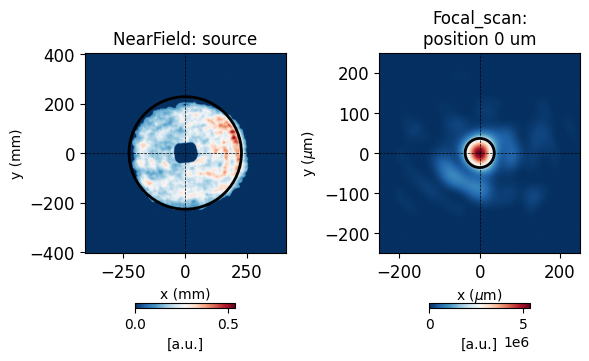

In [7]:
#Plotting images
figsize = (6,4)
aspect = 'equal'
origin='lower'
cmap='RdBu_r'
vmin=0
vmaxFF = ImgsFF[focus_index].image.max()
cut = 250
extentNF = np.array([ImgNF.limits['x'][0],ImgNF.limits['x'][1],
                    ImgNF.limits['y'][0],ImgNF.limits['y'][1]])
mosaic=[['A',0]]
fig0,ax = plt.subplot_mosaic(mosaic,figsize=figsize)
#1: NearField
imgnf=ax['A'].imshow(ImgNF.image,
                 cmap='RdBu_r',
                 extent=extentNF*1e3,
                 aspect=aspect,
                 origin=origin,
                 vmin=0)
ax['A'].set_xlabel(r'x (mm)')
ax['A'].set_ylabel(r'y (mm)')
ax['A'].tick_params(labelsize=12)
ax['A'].set_title('NearField: source')
ax['A'].axhline(0,ls='--',c='k',lw=.5)
ax['A'].axvline(0,ls='--',c='k',lw=.5)
diam = ImgNF.estimated_beam_diameter
nx,ny = ImgNF.CenterOfMassIndx.values()
center = np.array([ImgNF.x[nx],ImgNF.y[ny]])*1e3
circ = Circle(center,radius=diam/2*1e3,edgecolor='k',lw=2,fill=False)
ax['A'].add_patch(circ)
fig0.colorbar(imgnf,
             orientation='horizontal',
               shrink=0.5).set_label('[a.u.]')
#FFfields
for j,ImgFF in enumerate(ImgsFF):
    extentFF = np.array([ImgFF.limits['x'][0],ImgFF.limits['x'][1],
                       ImgFF.limits['y'][0],ImgFF.limits['y'][1]])
    img1=ax[j].imshow(ImgFF.image,
                     cmap=cmap,
                     extent=extentFF*1e6,
                     aspect=aspect,
                     origin=origin,
                     vmin=vmin,
                     vmax=vmaxFF)
    ax[j].set_xlabel(r'x ($\mu$m)')
    ax[j].set_ylabel(r'y ($\mu$m)')
    ax[j].tick_params(labelsize=12)
    ax[j].axhline(0,ls='--',c='k',lw=.5)
    ax[j].axvline(0,ls='--',c='k',lw=.5)
    FFname = FFpaths[j].split('/')[-1].split('_')[-1].split('.')[0]
    ax[j].set_title(f'FarField:{FFname}')
    ax[j].set_title(f'Focal_scan:\nposition {planes_pos[j]*1e6:.0f} um')
    diam = ImgFF.estimated_beam_diameter
    nx,ny = ImgFF.CenterOfMassIndx.values()
    center = np.array([ImgFF.x[nx],ImgFF.y[ny]])*1e6
    circ = Circle(center,radius=diam/2*1e6,edgecolor='k',lw=2,fill=False)
    ax[j].add_patch(circ)
    if cut is not None:
        ax[j].set_xlim(-cut,cut)
        ax[j].set_ylim(-cut,cut)
    fig0.colorbar(img1,
                 orientation='horizontal',
                 shrink=0.5).set_label('[a.u.]')
    fig0.tight_layout()

<style>
    p {
        font-size:16pt;
        }
    code{
        color:white
        }
    li {
        margin:10px;
        font-size:14pt;
        }
    ol{
        line-height:130%
        }
</style>
<h3> 2) Propagation module </h3>

It solves the Fourier transformed Helmholtz equation, under paraxial approximation, on a re-scaled equivalent plane, closer to focal plane, in order to preserve the F#-number of the simulated system, so the physics of diffraction is preserved while achieving a proper resolution of the numerical focal spot.

<h4> Main functions </h4>
<ul>
    <li> <code>WorkingPlaneTransform</code>: deals with the equivalent plane rescaling; WARNING: it can also work without a FFimage. In this case it just advertises of the approximate resolution of the numerical focal spot.</li>
    <li> <code>BeamFocusing</code>: the actual propagator. </li>
</ul>

In [138]:
lambda0 = .81e-6
mirror = Mirror(F_dist,shape='Parabolic') # shape = str: 'Parabolic'|'Spherical'| any function with signature f(R,kz,F)
NzR = 4
adjust_F = False 
Beam = BeamFocusing(*WorkingPlaneTransform(ImgNF,
                                           None,
                                           mirror,
                                           lambda0,
                                           NzR,
                                           adjust_F))

With an estimated focal spot size of 53.53 um and a Rayleigh range of 11.11 mm,
the effective focal distance is F = 4.4 cm.


<style>
    p {
        font-size:16pt;
        }
    code{
        color:white
        }
    li {
        margin:10px;
        font-size:14pt;
        }
    ol{
        line-height:130%
        }
</style>
<h3> The <code>BeamFocusing</code> class </h3>
The actual signature of <code>BeamFocusing</code> is:
<ul>
    <li> Mirror: Mirror class instance </li>
    <li> lambda0: float, the wavelength</li>
    <li> I_dist: np.2darray, the intensity distribution of the input field</li>
    <li> x_lims,y_lims: list|tuple|np.1darray, the limits (re-scaled!) of the 2D box</li>
    <li> norm_radius: float, a normalization radius to define the unitary circle for the Zernike series (see .add_aberrations) </li>
    <li> oam: float=0, eventually a given orbital angular momentum</li>   
</ul>
<h4> Main methods </h4>
<ul>
    <li> .propagation(z:float|None,output:str='intensity'|'complex'|'real'|'imag')</li>
    <li> .add_aberrations(list|tuple|np.1darray()) </li>
    <li> .add_phase_mask(np.2darray)
</ul>

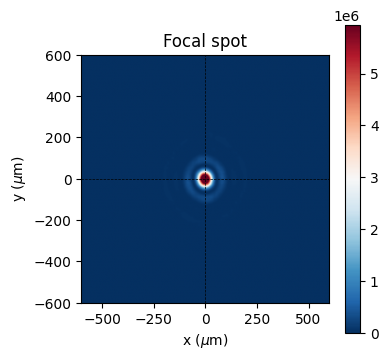

In [134]:
focus_image = Beam.propagation()
fig,ax = plt.subplots(1,1,figsize=(4,4))
extent = np.array([Beam.x_lims[0],Beam.x_lims[1],
                           Beam.y_lims[0],Beam.y_lims[1]])*1e6
cut = None
mappable=ax.imshow(focus_image,
          cmap=cmap,
          extent=extent,
          aspect=aspect,
          origin=origin,
          vmin=vmin,
          vmax=vmaxFF)
ax.set_xlabel(r'x ($\mu$m)')
ax.set_ylabel(r'y ($\mu$m)')
ax.set_title('Focal spot')
ax.axhline(0,ls='--',lw=.5,c='k')
ax.axvline(0,ls='--',lw=.5,c='k')
if cut is not None:
    ax.set_xlim(-cut,cut)
    ax.set_ylim(-cut,cut)
fig.colorbar(mappable)

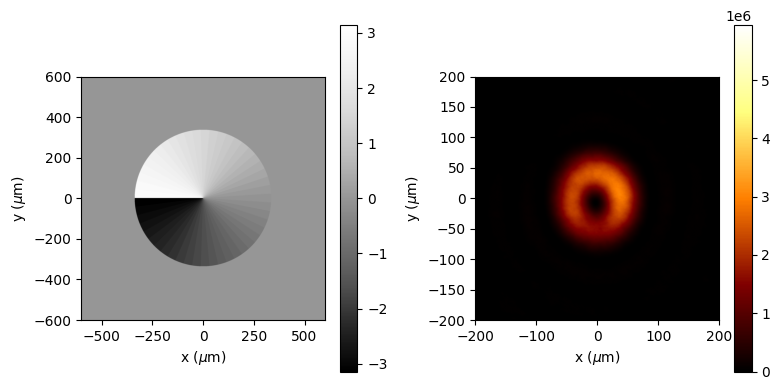

In [ ]:
"Adding a phase mask"
from lp4pic.utils.phasemasks import Pie

X,Y = np.meshgrid(Beam.x,Beam.y)
R,T = cart2pol(X,Y)
PM = Pie(T,50)
PM = pi*np.where(R>Beam.__radius__,0,PM)
Beam.apply_phase_mask(PM)
focus_image = Beam.propagation()

fig,ax = plt.subplots(1,2,figsize=(8,4))
extent = np.array([Beam.x_lims[0],Beam.x_lims[1],
                           Beam.y_lims[0],Beam.y_lims[1]])*1e6
cmaps = ['Greys_r','afmhot']
vmins = [-pi,0]
vmaxs = [pi,vmaxFF]
cut = 200
for i,image in enumerate([PM,focus_image]):
    mappable=ax[i].imshow(image,
              cmap=cmaps[i],
              extent=extent,
              aspect=aspect,
              origin=origin,
              vmin=vmins[i],
              vmax=vmaxs[i])
    ax[i].set_xlabel(r'x ($\mu$m)')
    ax[i].set_ylabel(r'y ($\mu$m)')

    if i==1 and cut is not None:
        ax[i].set_xlim(-cut,cut)
        ax[i].set_ylim(-cut,cut)
    fig.colorbar(mappable)
fig.tight_layout()


The number of aberration coefficients is not compatible
with required max radial order 3.
An aberration array of length = 10 was filled with zeros for the higher orders.


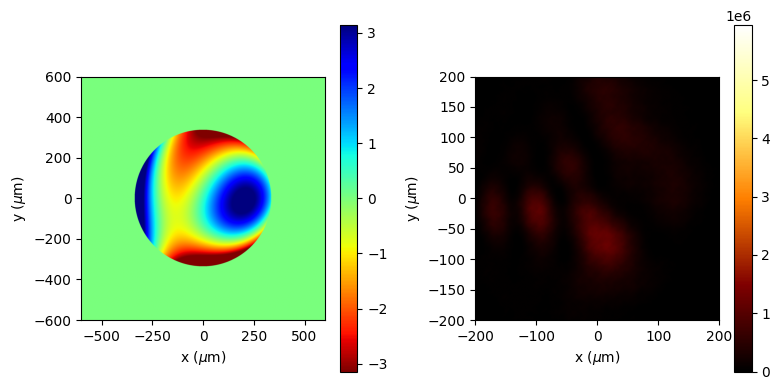

In [140]:
"Adding aberrations"
ab_array = [0,.4,0,-0.5,0,4,1,-3]
Beam.add_aberrations(ab_array)
W = np.zeros_like(Beam.ZernikeBank[0][0])
n_max_Zer = len(Beam.ZernikeBank)
for n in range(n_max_Zer):
    j_min = int(n*(n+1)/2)
    j_max = int((n+1)*(n+2)/2)
    a = Beam.Aberrations[j_min:j_max]
    for i,m in enumerate(Beam.ZernikeBank[n].keys()):
        W += a[i]*Beam.ZernikeBank[n][m]
focus_image = Beam.propagation()

fig,ax = plt.subplots(1,2,figsize=(8,4))
extent = np.array([Beam.x_lims[0],Beam.x_lims[1],
                           Beam.y_lims[0],Beam.y_lims[1]])*1e6
cmaps = ['jet_r','afmhot']
vmins = [-pi,0]
vmaxs = [pi,vmaxFF]
cut = 200
for i,image in enumerate([W,focus_image]):
    mappable=ax[i].imshow(image,
              cmap=cmaps[i],
              extent=extent,
              aspect=aspect,
              origin=origin,
              vmin=vmins[i],
              vmax=vmaxs[i])
    ax[i].set_xlabel(r'x ($\mu$m)')
    ax[i].set_ylabel(r'y ($\mu$m)')

    if i==1 and cut is not None:
        ax[i].set_xlim(-cut,cut)
        ax[i].set_ylim(-cut,cut)
    fig.colorbar(mappable)
fig.tight_layout()

<style>
    p {
        font-size:16pt;
        }
    code{
        color:white
        }
    li {
        margin:10px;
        font-size:14pt;
        }
    ol{
        line-height:130%
        }
</style>
<h3> 3) Phase reconstruction module </h3>

Comprises two sub-modules
<ul>
    <li> A Gerchberg-Saxton algorithm: <code>PhaseReconstructor</code></li>
    <li> A Genetic algorithm to optimize aberrations coefficients: <code>GeneticOptimizer</code></li>
</ul>

<style>
    p {
        font-size:16pt;
        }
    code{
        color:white
        }
    li {
        margin:10px;
        font-size:14pt;
        }
    ol{
        line-height:130%
        }
    img {
        display: block;
        margin: auto;
        width: 400px;
    }
</style>

<h4>GS algorithm in a pic</h4>
 <img src="imgs/gs_multiplane.png">

The algorithm retireve the phase of the incoming beam at the parabola's plane. Once the phase is retrieved, the <code>PhaseReconstructor</code> can projects this phase map onto the Zernike polynomial space to characterize the aberrations, finding the corresponding coefficients.  

In [ ]:
#%%#########################################
### __Gerchberg-Saxton phase retrieval__ ###
############################################
#Inputs to build the Phase Reconstructor
mirror = Mirror(F_dist,'Parabolic')
lambda0 = .81e-6
seed = 0
## Inputs for methods in the Phase Reconstructor:
#1) Phase retrieval
NzR = 10
N_gs = 100
focus_index = np.where(np.array(planes_pos)==0.0)[0][0]
adjust_F = False
mod = 'Sequential'    # 'Sequential'|'Random': in case of passing a focal scan as ImgsFF, the single GSA loop can proceed sequentially through all the planes or
                      # from the NF_plane to a FF_plane, randomically chosen at each iteration among the images stored in ImgsFF.
                      # With a single FF image, the two mods are equivalent.  
mod_dim = 11
#2) Phase projection
max_n_projection = 10 
phase_ret = PhaseReconstructor(ImgNF, ImgsFF, mirror, lambda0,
                               planes_pos=planes_pos,seed_phase=seed,save_dir=None)
phase_ret.GerSaxPhaseRetriever(NzR,N_gs,focus_index,adjust_F,align_max=False,
                               mod=mod,mod_dim=mod_dim,loss_func='MSE')
Beam = phase_ret.Propagator
Error = phase_ret.error/phase_ret.error[0]*100
# Phase projection: building of Aberrated (Zernike) Beam
Aberrations, projected_phase = phase_ret.Aberrometer(max_n_projection,
                                                     'unwrapped')
ImgFF = ImgsFF[focus_index]
AbBeam = BeamFocusing(*WorkingPlaneTransform(ImgNF,
                                             ImgFF,
                                             mirror,
                                             lambda0,
                                             NzR,
                                             adjust_F))
AbBeam.add_aberrations(Aberrations)


Ehi watch out!
At such distance the waist resolution is approximately 15 pixels,
less than experimental farfield resolution 91.


Seeding the Gerchberg-Saxton loop
\Running iteration 100/100: last round. Finish.Fieldld scan 1/1K


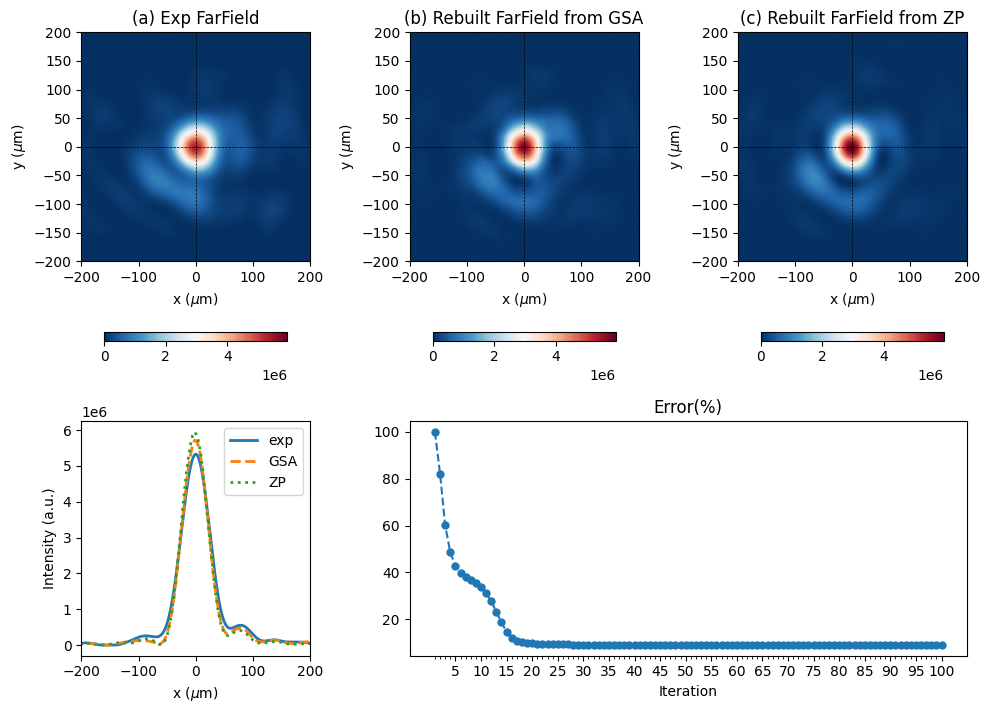

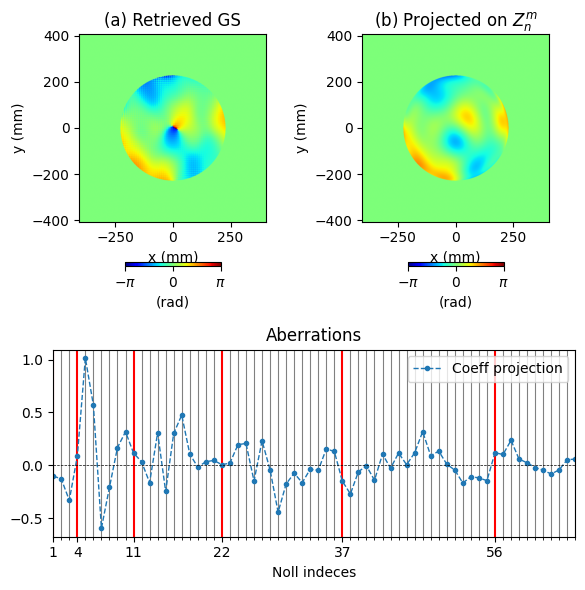

In [145]:
#Plotting
from functools import wraps

def add_method(cls):
    def decorator(func):
        @wraps(func)
        def wrapper(self,*args,**kwargs):
            return func(self,*args,**kwargs)
        setattr(cls,func.__name__,wrapper)
        return func
    return decorator

@add_method(plt.Axes)
def get_minor_gridlines(self,axis='x'):
    if axis == 'x':
        ticks=self.xaxis.get_minor_ticks()
    elif axis == 'y':
        ticks=self.yaxis.get_minor_ticks()
    return cbook.silent_list('Line2D gridLine',
                             [tick.gridline for tick in ticks])
#%% Preparing figures
##a) For intensity plots
figsize = (10,8)
aspect = 'equal'
origin='lower'
cmap='RdBu_r'
vmin=0
vmaxReb = vmaxFF
mosaic = [[0,1,2],
          [3,'D','D']]
height_ratios=(1,0.5)
fig0,ax = plt.subplot_mosaic(mosaic,figsize=figsize,
                             height_ratios=height_ratios)
##b)for phase plots
M=list()
for n in range(max_n_projection+1):
    for i in __generate_m__(n):
        M.append(i)
M = np.array(M) 
grid_indices, = np.where(M==0)
figsize=(6,6)
vmin_p,vmax_p = np.array([-pi,pi])
Mosaic = [[0,1,],
          ['e','e']]
height_ratios=(1,0.7)
fig,Ax = plt.subplot_mosaic(Mosaic,
                            figsize=figsize,
                            height_ratios=height_ratios)
im = Beam.propagation()
abim = AbBeam.propagation()
Ny,Nx = ImgNF.image.shape
ny,nx = (int(Ny/2+.5),int(Nx/2+.5))
MaxNoll = int((max_n_projection+1)*(max_n_projection+2)/2)
NollIndeces = np.arange(1,MaxNoll+1,dtype=int)
label_cb = '(rad)'
cb_ticks = [-pi,0,pi]
cb_ticks_labels = [r'$-\pi$',r'$0$',r'$\pi$']
#(1) Intensity plotter
for j,intensity in enumerate([ImgFF.image,im,abim]):
    if np.array_equal(intensity,ImgFF.image):
        extent = 1e6*np.array([[ext for ext in limits]\
                            for limits in ImgFF.limits.values()]).flatten()
        title = '(a) Exp FarField'
        ics = ImgFF.x*1e6
        label = 'exp'
        ls = 'solid'
    elif np.array_equal(intensity,im):
        extent = np.array([Beam.x_lims[0],Beam.x_lims[1],
                           Beam.y_lims[0],Beam.y_lims[1]])*1e6
        title = f'(b) Rebuilt FarField from GSA'
        ics = Beam.x*1e6
        label='GSA'
        ls = 'dashed'
    elif np.array_equal(intensity,abim):
        extent = np.array([AbBeam.x_lims[0],AbBeam.x_lims[1],
                           AbBeam.y_lims[0],AbBeam.y_lims[1]])*1e6
        title = f'(c) Rebuilt FarField from ZP'
        ics = AbBeam.x*1e6
        label='ZP'
        ls = 'dotted'
    img1=ax[j].imshow(intensity,
                     cmap=cmap,
                     extent=extent,
                     aspect=aspect,
                     origin=origin,
                     vmin=vmin,
                     vmax=vmaxFF)
    diam = ImgFF.estimated_beam_diameter
    ax[j].set_xlabel(r'x ($\mu$m)')
    ax[j].set_ylabel(r'y ($\mu$m)')
    ax[j].set_title(title)
    ax[j].axhline(0,ls='--',lw=.5,c='k')
    ax[j].axvline(0,ls='--',lw=.5,c='k')
    if cut is not None:
        ax[j].set_xlim(-cut,cut)
        ax[j].set_ylim(-cut,cut)
    fig0.colorbar(img1,
                 orientation='horizontal',
                 shrink=0.8)
    ax[3].plot(ics,intensity[int(len(ics)/2+.5),:],
               lw=2,label=label,ls=ls)
ax[3].set_xlabel(r'x ($\mu$m)')
ax[3].set_ylabel('Intensity (a.u.)')
if cut is not None:
    ax[3].set_xlim(-cut,cut)
ax[3].legend()
ax['D'].plot(np.array(range(N_gs))+1,Error,'o--',
             markersize=5)
ax['D'].set_xlabel('Iteration')
ax['D'].set_title('Error(%)')
if N_gs>=35:
    ax['D'].set_xticks(np.array(range(5,N_gs+1,5)))
    ax['D'].set_xticks(np.array(range(N_gs))+1,minor=True)
else:
    ax['D'].set_xticks(np.array(range(N_gs))+1)
for axes in ax.values():
    axes.tick_params(axis='both')
fig0.tight_layout()
#(2) Phase plotter
phase = phase_ret.retrieved_phase
Phase = np.where(Beam.R<=Beam.__radius__,phase,0)
Projected_phase = projected_phase-Aberrations[0]*AbBeam.ZernikeBank[0][0]
Titles = [f'(a) Retrieved GS','(b) Projected on $Z_n^m$']

phases = [Phase,Projected_phase]
for j,phase_map in enumerate(phases):
    cb_phase = fig.colorbar(Ax[j].imshow(phase_map,
                                         cmap='jet',
                                         origin='lower',
                                         extent=extentNF*1e3,
                                         vmin=vmin_p,
                                         vmax=vmax_p),
                            shrink=.4,location='bottom')
    cb_phase.set_label('(rad)')
    cb_phase.set_ticks(cb_ticks)
    cb_phase.set_ticklabels(cb_ticks_labels)
    Ax[j].set_title(Titles[j])
    Ax[j].set_xlabel(r'x (mm)')
    Ax[j].set_ylabel(r'y (mm)')

Ax['e'].plot(NollIndeces,Aberrations,'o--',
           markersize=3,label=f'Coeff projection',lw=1)
#(3) Finilizing plots aesthetic
if MaxNoll>21:
    Ax['e'].set_xticks(grid_indices+1)
    Ax['e'].set_xticks(NollIndeces,minor=True)
    M_grid_lines=Ax['e'].get_xgridlines()
    for Gl in M_grid_lines:
        Gl.set_linewidth(1.5)
        Gl.set_color('r')
    m_grid_lines = Ax['e'].get_minor_gridlines()
    for gl in m_grid_lines:
        gl.set_color('grey')
else:
    Ax['e'].set_xticks(NollIndeces)
    M_grid_lines=Ax['e'].get_xgridlines()
    for k,gl in enumerate(M_grid_lines):
        if k in grid_indices:
            gl.set_linewidth(1.5)
            gl.set_color('r')
        else:
            gl.set_linewidth(.5)
            gl.set_color('k')
Ax['e'].set_title('Aberrations')
Ax['e'].set_xlim(xmin=1,xmax=MaxNoll)
Ax['e'].grid(which='both',axis='x')
Ax['e'].axhline(0,ls='--',lw=.5,c='k')
Ax['e'].set_xlabel('Noll indeces')
Ax['e'].legend()
fig0.tight_layout()
fig.tight_layout()

<style>
    p {
        font-size:16pt;
        }
    code{
        color:white
        }
    li {
        margin:10px;
        font-size:14pt;
        }
    ol{
        line-height:130%
        }
    img {
        display: block;
        margin: auto;
        width: 400px;
    }
</style>

<h4>Genetic Optimisation  in a pic</h4>
 <img src="./imgs/GenAlg_img.png">

It is a "brute force" algorithm which applies a pivotal, randomically given, modification to a seeding aberrations array: for each epoch, it generates mutations of the same aberrations array, use them to produce a focal spot and the "fittest" array it is the one producing the focal spot that minimizes the error ("distance") from the experimental focal spot. The fittest array becomes the seed for the next epoch. The key parameters are the ones defining the "searching space" for mutations. 

The epoch can be "ACCEPTED" or "REJECTED": in the case of rejection the volume where finding pivotal modifications to coefficients is shrinked to refine the searching of the fittest.


In [97]:
#%%##########################################
### __Genetic Optimization of projected__ ###
#############################################
#Inputs for the optimizer
Nevolutions = 70
Ntrials = 100
BestError=1e30
NzR=10

"These three the searching space for mutations"
ScanAmplitude_max = 1.2
ScanAmplitude_min = .01
DecayIteration = 8

limits = {'x':[-250e-6,250e-6],'y':[-250e-6,250e-6]}
#%% Genetic Optimization --> 2nd step to optimize the ab coefficients
##Re-init ImgNF with lower resolution to speed up
"""
WARNING: We have noticed that for the GeneticOptimisation one desn't need the full resolved NearField image.
 It works also with an undersolved image, that is why we re.read a temporary NF image, then we substitute to the obtained
 BeamFocusing object the original, full-resolved profile.
"""
tmp_ImgNF = ReadImages(NFpath,
                  calibration=calibNF,
                  threshold=threshNF,
                  com_mode=NFcom_method,
                  remove_bg=NFremove_bg,
                  SGfilt_order=NFfilt_order,
                  blur_dict=NFblur_dict,
                  change_res=.3,
                  square_img=True,
                  offset=offsetNF,
                  activate_blur=True)

AbBeam_opt, Iterations, Errors = GeneticOptimizer(tmp_ImgNF,ImgFF,
                                    mirror,lambda0,NzR,
                                    Nevolutions,Ntrials,
                                    best_err=BestError,
                                    scan_amp_max=ScanAmplitude_max,
                                    scan_amp_min=ScanAmplitude_min,
                                    decay_it=DecayIteration,
                                    ab_array=Aberrations,
                                    save_dir=None,
                                    ab_rnd_search=False,
                                    save_rnd=False,
                                    save_evo=False,
                                    adjust_F=adjust_F,
                                    loss_func='MSE',
                                    limits=limits)

Aberrations_opt = AbBeam_opt.Aberrations
s = AbBeam_opt.x_lims[0]/ImgNF.limits['x'][0]
AbBeam_opt.substitute_intensity(ImgNF.image/s**2)
abim_opt=AbBeam_opt.propagation()


Ehi watch out!
At such distance the waist resolution is approximately 4 pixels,
less than experimental farfield resolution 91.


Using MSE for error evaluation.
Evolution 1/70
**Increasing the scan radius after 10 evolutions**
  Now N=0 and delta=1.210000e+00.
  Next rejection will update delta=3.926879e-01  with N=1
Evolution accepted.0
Evolution 2/70
--Trial 100/100, with delta=1.210000e+00
 Evolution rejected. 
 Updating mutations radius with N=1 
Evolution 3/70
--Trial 100/100, with delta=3.926879e-01
 Evolution rejected. 
 Updating mutations radius with N=2 
Evolution 4/70
Evolution accepted.1
Evolution 5/70
Evolution accepted.1
Evolution 6/70
Evolution accepted.1
Evolution 7/70
Evolution accepted.1
Evolution 8/70
Evolution accepted.1
Evolution 9/70
Evolution accepted.1
Evolution 10/70
Evolution accepted.1
Evolution 11/70
**Increasing the scan radius after 10 evolutions**
  Now N=0 and delta=1.320417e-01.
  Next rejection will update delta=3.926879e-01  with N=1
Evolution accepted.1
Evolution 12/70
Evolution accepted.1
Evolution 13/70
Evolution accepted.1
Evolution 14/70
Evolution accepted.1
Evolution 15/70

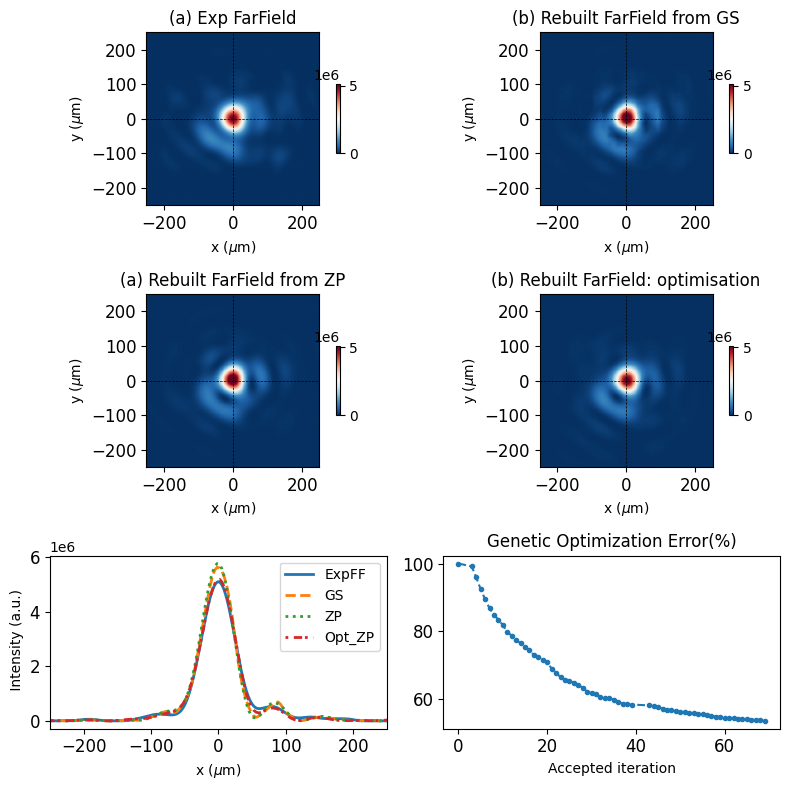

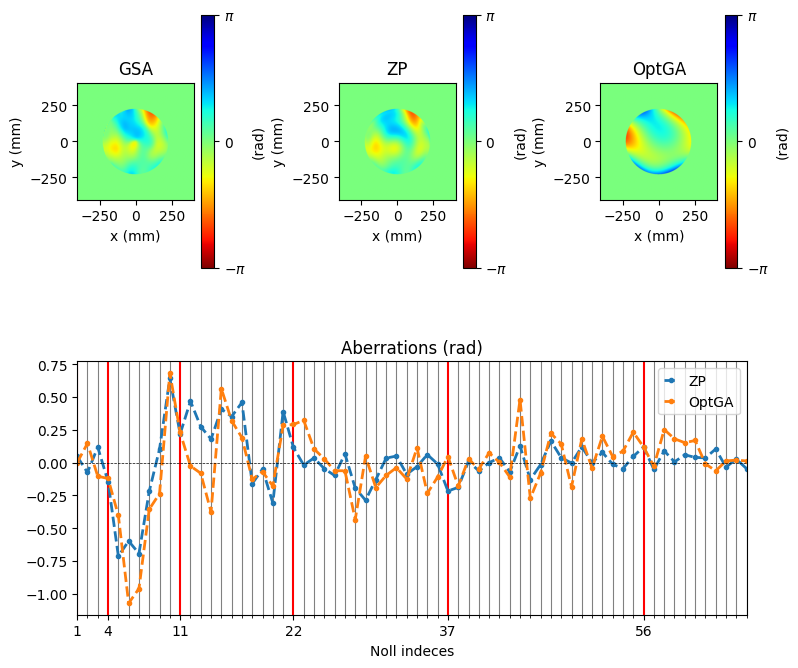

In [104]:
#Plotting
#%% Plotting optimized results
#(1) Intensity plotter
power_norm_gamma = 1
figsize=(8,8)
mosaic = [[0,1],
          [2,3],
          [4,5]]
im = Beam.propagation()
Fig0,AX = plt.subplot_mosaic(mosaic,figsize=figsize)
for j,t in enumerate([ImgFF.image,im,abim,abim_opt]):
    if np.array_equal(t,ImgFF.image):
        title = '(a) Exp FarField'
        extent = np.array([ImgFF.limits['x'][0],ImgFF.limits['x'][1],
                          ImgFF.limits['y'][0],ImgFF.limits['y'][1]])
        ics = ImgFF.x*1e6
        label = 'ExpFF'
        ls='solid'
    elif np.array_equal(t,im):
        title = f'(b) Rebuilt FarField from GS'
        extent = np.array([Beam.x_lims[0],AbBeam.x_lims[1],
                           Beam.y_lims[0],Beam.y_lims[1]])
        ics = Beam.x*1e6
        label = 'GS'
        ls='dashed'
    elif np.array_equal(t,abim):
        title = f'(a) Rebuilt FarField from ZP'
        extent = np.array([AbBeam.x_lims[0],AbBeam.x_lims[1],
                           AbBeam.y_lims[0],AbBeam.y_lims[1]])
        ics = AbBeam.x*1e6
        label = 'ZP'
        ls='dotted'
    elif np.array_equal(t,abim_opt):
        title = f'(b) Rebuilt FarField: optimisation'
        extent = np.array([AbBeam_opt.x_lims[0],AbBeam_opt.x_lims[1],
                           AbBeam_opt.y_lims[0],AbBeam_opt.y_lims[1]])
        ics = AbBeam_opt.x*1e6
        label='Opt_ZP'
        ls=(0,(1,2,3,1))
    img=AX[j].imshow(t,
                 cmap=cmap,
                 norm = plt.matplotlib.colors.PowerNorm(gamma=power_norm_gamma,
                                                        vmin=vmin,
                                                        vmax=vmaxReb),
                 origin=origin,
                 extent=extent*1e6,
                 aspect=aspect)
    AX[j].set_xlabel(r'x ($\mu$m)')
    AX[j].set_ylabel(r'y ($\mu$m)')
    AX[j].axhline(0,ls='--',lw=.5,c='k')
    AX[j].axvline(0,ls='--',lw=.5,c='k')
    AX[j].set_title(title)
    AX[4].plot(ics,t[int(len(t[:,0])/2+.5),:],label=label,lw=2,ls=ls)
    if cut is not None:
        AX[j].set_xlim(-cut,cut)
        AX[j].set_ylim(-cut,cut)
        AX[4].set_xlim(-cut,cut)
    Fig0.colorbar(img,
                 orientation='vertical',
                 shrink=0.4)
AX[5].plot(Iterations,Errors/Errors[0]*100,'o--',markersize=3)
AX[5].set_title('Genetic Optimization Error(%)')
AX[5].set_xlabel('Accepted iteration')
AX[4].legend()
AX[4].set_xlabel(r'x ($\mu$m)')
AX[4].set_ylabel(r' Intensity (a.u.)')
for axes in AX.values():
    axes.tick_params(labelsize=12)

#(2) Phase plotter
figsize=(8,8)
Mosaic = [[0,1,2],
          [4,4,4]]
height_ratios=(1,.5)
Fig,aX = plt.subplot_mosaic(Mosaic,
                            figsize=figsize,
                            height_ratios=height_ratios)
opt_phase = np.zeros_like(AbBeam.ZernikeBank[0][0])
for n in range(n_max_Zer+1):
    Zn = AbBeam.ZernikeBank[n]
    jmin = int(n*(n+1)/2)
    jmax = int((n+1)*(n+2)/2)
    coeff = Aberrations_opt[jmin:jmax]
    for j,(m,Znm) in enumerate(Zn.items()):
        opt_phase = opt_phase + coeff[j]*Znm
Opt_phase = opt_phase
for j,phs in enumerate([Phase,Projected_phase,Opt_phase]):
    if j==0:
        title = f'GSA'
    elif j==1:
        title = f'ZP'
        abr = Aberrations
        MaxNoll = int((max_n_projection+1)*(max_n_projection+2)/2)
        NollIndeces = np.arange(1,MaxNoll+1,dtype=int)
    elif j==2:
        title = 'OptGA'
        abr = Aberrations_opt
        MaxNoll = int((max_n_projection+1)*(max_n_projection+2)/2)
        NollIndeces = np.arange(1,MaxNoll+1,dtype=int)
    img_phs = aX[j].imshow(phs,
                   cmap='jet_r',
                   origin='lower',
                   extent=extentNF*1e3,
                   vmin=vmin_p,
                   vmax=vmax_p)
    aX[j].set_title(title)
    aX[j].set_xlabel(r'x (mm)')
    aX[j].set_ylabel(r'y (mm)')
    cb_phase = Fig.colorbar(img_phs,shrink=.5,location='right')
    cb_phase.set_label(label_cb)
    cb_phase.set_ticks(cb_ticks)
    cb_phase.set_ticklabels(cb_ticks_labels)
    if not np.array_equal(phs,Phase):
        aX[4].plot(NollIndeces,abr,'o--',markersize=3,label=title,lw=2)
#(3) Finilizing plots aesthetic
if MaxNoll>21:
    aX[4].set_xticks(grid_indices+1)
    aX[4].set_xticks(NollIndeces,minor=True)
    M_grid_lines=aX[4].get_xgridlines()
    for Gl in M_grid_lines:
        Gl.set_linewidth(1.5)
        Gl.set_color('r')
    m_grid_lines = aX[4].get_minor_gridlines()
    for gl in m_grid_lines:
        gl.set_color('grey')
else:
    aX[4].set_xticks(NollIndeces)
    M_grid_lines=aX[4].get_xgridlines()
    for k,gl in enumerate(M_grid_lines):
        if k in grid_indices:
            gl.set_linewidth(1.5)
            gl.set_color('r')
        else:
            gl.set_linewidth(.5)
            gl.set_color('k')
aX[4].set_title('Aberrations (rad)')
aX[4].set_xlim(xmin=1,xmax=MaxNoll)
aX[4].grid(which='both',axis='x')
aX[4].axhline(0,ls='--',lw=.5,c='k')
aX[4].set_xlabel('Noll indeces')
aX[4].legend(handlelength=1)
Fig0.tight_layout()
Fig.tight_layout()

<style>
    p {
        font-size:16pt;
        }
    code{
        color:white
        }
    li {
        margin:10px;
        font-size:14pt;
        }
    ol{
        line-height:130%
        }
</style>

<h3> 4) The FBPIC interface </h3>

It is a custom Laser class of FBPIC to be initialized on the simulation grid through the <code>add_laser_pulse</code> method of FBPIC.
At its core, the <code>FromXYZArrayLaser</code> class in LP4PIC it is an interpolator with the following signature 

In [ ]:
def filter_out(x,y):
    """
    Filter function to remove laser pulse residual 
    at box boundaries.
    """
    f = np.exp(-1.5*((x**2+y**2)/rmax**2)**8)
    return f
tau_FWHM = 25e-15 	  # Laser FWHM duration (s)
tau = tau_FWHM/np.sqrt(np.log(4))
t = np.linspace(-3*tau,3*tau,2000)
ctau = c*tau
z0 = -3*ctau          
FocalDistance = Beam.Mirror.focal_distance
FocalPosition = 1200e-6
total_energy = 5 #(J)
pol = [1,1j]
# temporal profile
Ez = np.exp(-(t**2/tau**2))
# transverse distribution
Er  = AbBeam_opt.propagation(output='complex',z=FocalDistance-(FocalPosition-z0))

laser = LaserFromDataArrays(energy=AbBeam_opt.transmission*total_energy,
                          tran_data=Er, x_lims=AbBeam_opt.x_lims, y_lims=AbBeam_opt.y_lims,
                          long_data=Ez, t_lims=[t.min(),t.max()],
                          z0=z0, wavelength=lambda0, pol=pol, propagation_direction=1,
                          filtering=None,center_data=False)

"""
Inside the FBPIC simulation script this 'laser' object is initialized:

    sim = Simulation( Nz, zmax, Nr, rmax, Nm, dt, zmin=zmin,
                      v_comoving=v_comoving, gamma_boost=boost.gamma0,
                      n_order=n_order, use_cuda=use_cuda,
                      boundaries={'z':'open', 'r':'open'})
    .
    .
    .
    add_laser_pulse( sim, laser, gamma_boost=boost.gamma0,
                    method='antenna',z0_antenna=zmin+5e-6)
"""
"""
WARNING: in lab_frame it works with method = 'direct', easier to get; in lorentz_boost it works only with method='antenna'
and centroid "z0" must be not so far 0 (max tens of microns) 
"""

'\nWARNING: in lab_frame it works with method = \'direct\', in lorentz_boost it works only with method=\'antenna\'\nand centroid "z0" must be not so far 0 (max tens of microns) \n'